# exp1.ipynb
## Experiment Analysis for Training ML Based on Supervised Data and Optimizing Reward Functions (RNN)
### Purpose
The purpose of this notebook is to begin training and understanding the data received from experimentation in building a multiclass classifier model for tip conditions. The main source of the reinforcement learning in this notebook will be from other libraries, such as torch and scitools, but the following experiment outline identifies how we have set up data collection for training.

### Experimental Methodology
Classify a new tip/cantilever pair into a "good" condition class, and using a calibration sample material, iteratively take images while gradually increasing tip pressure and speed to induce wear on the tip. Classify images by their index number, i.e. images 1-4 will be considered in the "good" class, while images 5-8 "worse", and so on until image 17-20, where we classify the tip as "worn out/broken."

The training of a ML model to take a sample image and classify the wear of the tip will follow standard statistical outliers and the ability for the model to take periodic samples from trace and retrace data to make a prediction as a trend. This assumes that the **tip behavior does not change very much within single image scans, but does in the set of 20 scans**. So, the goal of this notebook is to be able to feed the model some sample of image scan data and have it predict the wear status of the tip.

Other important metrics that fuel the decision of the model can be used to point to the causes for tip wear, although it is likely that the scan number will be the main cause.

### Workflow
The main workflow for this notebook follows research on using reinforcement learning and supervised training as a hybrid approach to building a classifier model.

We will start with using a pre-trained image detection model, such as ImageNetV2 (https://imagenetv2.org/), and reinforcing its classification with trained data. The goal is to optimize some reward function, which we will experimentally define.

Ultimately, after discussion, it appears that that the most important metrics to classification will be:
+ **MAE of the trace/retrace in the height plot**.
+ **Standard deviation of the phase, or the variance of the hysteresis curve, where applicable**.
+ **Index number and supervised classification of tip condition**
+ **Scan rate and pressure on the tip**

**So, we should start with importing a pre-trained image model. The choice here will be ImageNet.**


In [4]:
import torch                                        # For ML libraries/training
import torchvision.models as models                 # For accessing vision/image-based models

!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


Looking in indexes: https://download.pytorch.org/whl/cu128


In [5]:
model = models.resnet18(weights='IMAGENET1K_V1')    # Load the pre-trained model (ResNet18)
model.eval()

"""
The "IMAGENET1K_V1 tells PyTorch to configure the model based on ImageNet weights.
"""

'\nThe "IMAGENET1K_V1 tells PyTorch to configure the model based on ImageNet weights.\n'

There is some consideration about cost and speed for training this model. Since image-based models are quite resource intensive (as any large model may be), it is generally recommended to use hardware acceleration from GPUs. For now, we will attempt to use local hardware (Apple Silicon) to train and process this model.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cuda')
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

We will likely need to process .ibw files and open them as pandas dataframes or other relevant datastructures, then resize and normalize to fit the model for training. We can then define the reward function for reinforcement learning.


In [7]:
"""
Adaptation of the API to handle this data case:

Each given sample image contains 8 channels (4 with trace and retrace), of which we need to fix some
functions to work with their name scheme.
"""

from igor2 import binarywave as bw
import numpy as np

def load_ibw(file, ss=False):
    '''
    Load the ibw file as an IBWData object.

    Input:
        file     - String: path to the ibw file
        ss         - Boolean: if True then the ibw file will be treated as domain switching
                 spectroscopy file.
    Output:
        IBWData object:
        self.z          - Numpy array: 2D numpy array containing topography channel. 
                         Default is the "Height" channel.
        self.size       - float: Map size in the unit of meter
        self.mode        - String: Imaging mode. Currently support "AC Mode", "Contact Mode", "PFM Mode"
                         "SS Mode" and "DART Mode".
        self.header     - Dict: All the setup information.
        self.channels   - list: List of channel names
        self.data       - Numpy array: An array of all the saved image data in this ibw file in
                         the same order as self.channels
    Examples:
        
    '''
    
    # Return an IBWData object
    return IBWData(file, ss=ss)

class IBWData(object):
    '''
    Data structure for AR IBW maps.

    Attributes:
        self.z          - Numpy array: 2D numpy array containing topography channel. 
                         Default is the "Height" channel.
        self.size       - float: Map size in the unit of meter
        self.mode        - String: Imaging mode. Currently support "AC Mode", "Contact Mode", "PFM Mode"
                         "Spec" and "DART Mode".
        self.header     - Dict: All the setup information.
        self.channels   - list: List of channel names
        self.data       - Numpy array: An array of all the saved image data in this ibw file in
                         the same order as self.channels
        
    Methods:
        None
    '''
    def __init__(self, path, ss=False):
        super(IBWData, self).__init__()

        self._load_ibw(path)

        # Spectroscopy files:
        if ss == True:
            self.mode = "Spec"
            try:
                self._load_ss()
            except IndexError:
                pass
        elif "ARDoIVCurve" in self.header:
            self.mode = "Spec"
            try:
                self._load_ss()
            except IndexError:
                pass
        # Image files:
        else:
            try:
                self.size = self.header['ScanSize']
                self.mode = self.header['ImagingMode']
                z_index = self.channels.index('Height')
                self.z = self.data[z_index]
                
                try:
                    # Separate DART mode from general PFM mode
                    if self.mode == "PFM Mode" or self.mode == "AC Mode":
                        if len(self.channels) > 4 and len(self.channels) < 8:
                            self.mode = "DART Mode"
                            self.channels = ['Height', 'Amplitude1', 'Amplitude2', 'Phase1', 'Phase2', 'Frequency']
                        elif len(self.channels) > 7:
                            self.channels = ['Height (T)', 'Height (RT)', 'Amplitude (T)', 'Amplitude (RT)',
                                            'Phase (T)', 'Phase (RT)', 'ZSensor (T)', 'ZSensor (RT)']
                        else:
                            self.channels = ['Height', 'Amplitude', 'Deflection', 'Phase']
                except IndexError:
                    pass
            except KeyError:
                pass

    def _load_ibw(self, path):

        t = bw.load(path)
        wave = t.get('wave')

        # Decode the notes section to parse the header
        if isinstance(wave['note'], bytes):
            try:
                parsed_string = wave['note'].decode('utf-8').split('\r')
            except:
                parsed_string = wave['note'].decode('ISO-8859-1').split('\r')

        # Load the header
        self.header = {}

        for item in parsed_string:
            try:
                key, value = item.split(':', 1)
                value = value.strip()  # Remove leading/trailing whitespace
            except ValueError:
                continue  # For items that do not split correctly

            # Determine the data type of the value and convert
            if '.' in value or 'e' in value:  # Floating point check
                try:
                    self.header[key] = float(value)
                except ValueError:
                    self.header[key] = value
            elif value.lstrip('-').isdigit():  # Integer check
                self.header[key] = int(value)
            else:
                self.header[key] = value

        # Load the data
        # Transpose the data matrix
        self.data = wave['wData'].T
        # data = wave['wData']

        # Load the channel names
        self.channels = [self.header.get(f'Channel{i+1}DataType', 'Unknown') for i in range(np.shape(self.data)[0])]

    def _load_ss(self, nan=True, drop=0.1):

        if nan is True:
            bias_raw= self.data[-1]
            index_not_nan = np.where(~np.isnan(bias_raw))

            bias = bias_raw[index_not_nan]
            amp1, amp2, phase1, phase2, freq = self.data[1][index_not_nan], self.data[2][index_not_nan], self.data[3][index_not_nan], \
                        self.data[4][index_not_nan], self.data[5][index_not_nan]
        else:
            bias = self.data[-1]
            amp1 = self.data[1]
            amp2 = self.data[2]
            phase1 = self.data[3]
            phase2 = self.data[4]
            freq = self.data[5]

        #Correcting first without offset to calculate the drive parameters
        phase1 = self._correct_phase_wrapping(phase1, offset_correction=False)
        phase2 = self._correct_phase_wrapping(phase2, offset_correction=False)

        df = self.header['DFRTFrequencyWidth']

        a_dr, ph_dr, q = self._calc_drive_params(amp1, amp2, phase1/180*np.pi, phase2/180*np.pi, freq, df)

        phase1 = self._correct_phase_wrapping(phase1)
        phase2 = self._correct_phase_wrapping(phase2)
        ph_dr  = self._correct_phase_wrapping(ph_dr/np.pi*180)

        # Let's count how many times the bias has changed (on->off, off->on)
        index_bp = np.where(np.diff(bias) != 0)[0] + 1
        # We define the width of applied voltage by the first non-zero voltage plateau
        index_delta = index_bp[1] - index_bp[0]
        # We drop the first segment of zero bias signals as this is the initial settling time
        index_bp = np.concatenate([[index_bp[0]-index_delta], index_bp])

        # Output array length
        length = len(index_bp) // 2

        bias_on, bias_off = np.zeros(length), np.zeros(length)

        phase1_on,phase1_off = np.zeros(length), np.zeros(length)
        phase2_on, phase2_off  = np.zeros(length), np.zeros(length)
        amp_on, amp_off = np.zeros(length), np.zeros(length)
        amp1_on, amp1_off = np.zeros(length), np.zeros(length)
        amp2_on, amp2_off = np.zeros(length), np.zeros(length)
        freq_on, freq_off = np.zeros(length), np.zeros(length)

        amp_dr_on, amp_dr_off = np.zeros(length), np.zeros(length)
        phase_dr_on, phase_dr_off = np.zeros(length), np.zeros(length)
        q_on, q_off = np.zeros(length), np.zeros(length)

        # We drop the first and last 10% data to avoid oscillation after bias change (10% settling time)
        skip = int(drop * index_delta)
        
        for i in range(length * 2-1):
            start = index_bp[i] + skip
            end = index_bp[i+1] - skip
            if i % 2 == 0: # bias off
                phase1_off[i//2] = np.mean(phase1[start:end])
                phase2_off[i//2] = np.mean(phase2[start:end])
                amp1_off[i//2] = np.mean(amp1[start:end])
                amp2_off[i//2] = np.mean(amp2[start:end])
                freq_off[i//2] = np.mean(freq[start:end])
                bias_off[i//2] = np.mean(bias[start:end])

                phase_dr_off[i // 2] = np.mean(ph_dr[start:end])
                q_off[i // 2] = np.mean(q[start:end])
                amp_dr_off[i // 2] = np.mean(a_dr[start:end])

            else:
                bias_on[i//2] = np.mean(bias[start:end])
                phase1_on[i//2] = np.mean(phase1[start:end])
                phase2_on[i//2] = np.mean(phase2[start:end])
                amp1_on[i//2] = np.mean(amp1[start:end])
                amp2_on[i//2] = np.mean(amp2[start:end])
                freq_on[i//2] = np.mean(freq[start:end])

                phase_dr_on[i // 2] = np.mean(ph_dr[start:end])
                q_on[i // 2] = np.mean(q[start:end])
                amp_dr_on[i // 2] = np.mean(a_dr[start:end])

        self.bias = bias_on
        self.phase1_on = phase1_on
        self.phase1_off = phase1_off
        self.phase2_on = phase2_on
        self.phase2_off = phase2_off
        self.freq_on = freq_on
        self.freq_off = freq_off
        self.amp_on = amp1_on
        self.amp_off = amp1_off
        self.amp1_on = amp1_on
        self.amp1_off = amp1_off
        self.amp2_on = amp2_on
        self.amp2_off = amp2_off
        self.x_on = amp_on * np.cos(phase1_on/180*np.pi)
        self.x_off = amp_off * np.cos(phase1_off / 180 * np.pi)

        self.amp_dr_on = amp_dr_on
        self.amp_dr_off = amp_dr_off
        self.x_dr_on = amp_dr_on * np.cos(phase_dr_on / 180 * np.pi)
        self.x_dr_off = amp_dr_off * np.cos(phase_dr_off / 180 * np.pi)
        self.phase_dr_on = phase_dr_on
        self.phase_dr_off = phase_dr_off
        self.q_on = q_on
        self.q_off = q_off

        # return bias[1:], amp_off[1:], phase1_off[1:], phase2_off[1:]

    def _correct_phase_wrapping(self, ph, lower=-90, upper=270, offset_correction=True):
        '''
        Correct the phase wrapping in Jupiter.
        
        Input:
            Ph     - Array: array of phase values
            lower - float: lower bound of phase limit in your instrument
            upper - float: upper bound of phase limit in your instrument
        Output:
            ph_shift - Array: phase with wrapping corrected
        '''
        # Use the phase value measured at last pixel as the offset in the lock-in
        if offset_correction:
            ph_shift = ph - ph[-1]
        else:
            ph_shift = ph

        index_upper = np.where(ph_shift > upper)
        index_lower = np.where(ph_shift < lower)
        ph_shift[index_upper] -= 360
        ph_shift[index_lower] += 360

        return ph_shift

    @staticmethod
    def _calc_drive_params(_a1, _a2, _ph1, _ph2, _fc, _df):
        '''
        Calculate real Dart parameters from the observables.

        Input:
            _a1  - amplitude 1
            _a2  - amplitude 2
            _ph1 - phase 1
            _ph2 - phase 2
            _fc  - resonance frequency
            _df  - difference between freq 2 and freq 1
        Output:
            _a_drive  - drive amplitude
            _ph_drive - resonance phase
            _q        - resonanse quality factor
        '''

        epsilon = 1e-10  # a small adding for calculation stability
        _dph = _ph2 - _ph1
        _f1 = _fc - _df / 2
        _f2 = _fc + _df / 2

        _om = _f1 * _a1 / (_f2 * _a2)
        _fi = np.tan(_dph)

        _x1 = -(1 - np.sign(_fi) * np.sqrt(1 + np.square(_fi)) / _om) / (_fi + epsilon)
        _x2 = (1 - np.sign(_fi) * np.sqrt(1 + np.square(_fi)) * _om) / (_fi + epsilon)

        _q = np.sqrt(_f1 * _f2 * (_f2 * _x1 - _f1 * _x2) * (_f1 * _x1 - _f2 * _x2)) / (np.square(_f2) - np.square(_f1))
        _q[_q > 1000] = 1000
        _a_drive = _a1 * np.sqrt((_fc**2 - _f1**2)**2 +(_fc * _f1 / _q)**2) / np.square(_fc)
        _ph_drive = _ph1 - np.arctan(_fc * _f1 / (_q * (np.square(_fc) - np.square(_f1))))

        return _a_drive, _ph_drive, _q

In [8]:
import aespm.tools as at
import pandas as pd
import os

def summarize_ibw_file(filename):
    """
    Prints a summary of information available in a .ibw file.
    """

    ibw = load_ibw(filename)

    print("File :", filename)
    print("Imaging Mode :", ibw.mode)
    print("Scan Size :", ibw.size)
    print("Header keys :", list(ibw.header.keys()))

    # Header keys are not defined for this sample, since they only go to four channels
    # Instead, we *know* the label style, so we can just give the channels each name and capture
    # the data that way.

    print("Available Channels :", ibw.channels)
    print("Data Shape :", ibw.data.shape)

    df = pd.DataFrame(ibw.data[0])
    df.to_csv('ibw_dataframe.csv', index=False)

    return ibw

def main():
    # Directory containing the .ibw files
    ibw_dir = "exp_data/June 18/read_out"

    # at.display_ibw_folder(ibw_dir, key=['Height', 'Phase', 'None'])

    # Directory containing the .ibw files
    ibw_dir = "exp_data/June 18/read_out"


    file_path = 'exp_data/June 18/wear_out/Wear_out_0034.ibw'
    summarize_ibw_file(file_path)


if __name__ == "__main__":
    main()



File : exp_data/June 18/wear_out/Wear_out_0034.ibw
Imaging Mode : AC Mode
Scan Size : 1e-05
Header keys : ['ScanSize', 'FastScanSize', 'SlowScanSize', 'ScanRate', 'XOffset', 'YOffset', 'PointsLines', 'ScanPoints', 'ScanLines', 'ScanAngle', 'ImagingMode', 'InvOLS', 'SpringConstant', 'AmpInvOLS', 'Amp2Invols', 'FastRatio', 'SlowRatio', 'TopLine', 'BottomLine', 'ScanMode', 'NapMode', 'FMapScanTime', 'FMapScanPoints', 'FMapScanLines', 'FMapXYVelocity', 'FMapBookWise', 'Channel1DataType', 'DataTypeSum', 'PhaseOffset', 'PhaseOffset1', 'NapPhaseOffset', 'VoltageParm', 'NapParms', 'PreScanSetting', 'OrcaOffset', 'OrcaOffset2', 'UserIn0Gain', 'UserIn0Offset', 'UserIn1Gain', 'UserIn1Offset', 'UserIn2Gain', 'UserIn2Offset', 'LateralGain', 'LateralOffset', 'OrcaGain', 'OrcaGain2', 'FastMapScanRate', 'FastMapZRate', 'dcdvPhaseOffset', 'dcdZPhaseOffset', 'FastReturnLines', 'BackPackIn0Offset', 'BackPackIn0Gain', 'BackPackIn1Offset', 'BackPackIn1Gain', 'BackPackIn2Offset', 'BackPackIn2Gain', 'BackPac

## We can now access each image type for trace and retrace. This will be important for generalizing trends.



In [9]:
import numpy as np

# def compute_reward(ibw_data, trace_idx=0, retrace_idx=1):
#     """
#     Compute reward based on IBWData object.
#     - ibw_data: your loaded IBWData instance with attributes:
#       .data shape (channels, H, W), channels named in ibw_data.channels
#     - trace_idx and retrace_idx: indices corresponding to trace and retrace data slices,
#       if separate. If not separate, you may need to infer or segment.
    
#     Returns:
#         reward (float): higher is better
#     """
#     # Extract channels indices
#     ch_names = ibw_data.channels
    
#     # Height channel data: shape (H, W)
#     trace = ibw_data.data[ch_names.index('Height (T)')] 
#     retrace = ibw_data.data[ch_names.index('Height (RT)')]
    
#     # MAE between trace and retrace heights
#     mae_height = np.mean(np.abs(trace - retrace))
    
#     # Phase channel noise (std dev of phase difference trace vs retrace)
#     phase_trace = ibw_data.data[ch_names.index('Phase (T)')]
#     phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
#     phase_noise = np.std(phase_trace - phase_retrace)
    
#     # Metadata: scan rate (normalize reward by it)
#     scan_rate = ibw_data.header.get('ScanRate', 1.0)  # fallback to 1.0 if missing
    
#     # Compose reward: inverse of error & noise, normalized by scan rate
#     reward = 1 / (mae_height + 1e-6) + 1 / (phase_noise + 1e-6)
#     reward /= scan_rate
    
#     return reward

# ibw = load_ibw("exp_data/June 18/read_out/Read_out_0000.ibw")
# compute_reward(ibw)


In [10]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(pretrained=True)

# Replace final layer for custom number of classes (e.g., 10)
num_classes = 5
model.fc = nn.Linear(model.fc.in_features, num_classes)

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import aespm.tools as at  # your IBW loader module
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
import torch.nn.functional as F


class AdaptiveLoss(nn.Module):
    def __init__(self):
        super(AdaptiveLoss, self).__init__()
        # Learnable weights for multi-task learning
        self.log_var_class = nn.Parameter(torch.zeros(1))
        self.log_var_reward = nn.Parameter(torch.zeros(1))
        
    def forward(self, class_pred, class_true, reward_pred, reward_true):
        # Classification loss
        class_loss = F.cross_entropy(class_pred, class_true)
        
        # Reward loss (MSE)
        reward_loss = F.mse_loss(reward_pred.squeeze(), reward_true)
        
        # Adaptive weighting based on uncertainty
        precision_class = torch.exp(-self.log_var_class)
        precision_reward = torch.exp(-self.log_var_reward)
        
        # Total loss with automatic balancing
        total_loss = (precision_class * class_loss + self.log_var_class + 
                     precision_reward * reward_loss + self.log_var_reward)
        
        return total_loss, class_loss, reward_loss


# --- Dataset class for loading IBW files ---
class IBWDataset(Dataset):
    def __init__(self, ibw_files, labels=None, transform=None, compute_rewards=False):
        self.ibw_files = ibw_files
        self.labels = labels
        self.transform = transform
        self.compute_rewards = compute_rewards
        
        # Pre-compute rewards if needed for efficiency
        if compute_rewards:
            self.rewards = []
            for i, file_path in enumerate(ibw_files):
                ibw_data = load_ibw(file_path)
                # Use improved reward function
                reward = compute_reward(ibw_data, scan_index=i+1)
                self.rewards.append(reward)
            
            # Normalize rewards to have zero mean and unit variance
            self.rewards = np.array(self.rewards)
            self.reward_mean = np.mean(self.rewards)
            self.reward_std = np.std(self.rewards)
            if self.reward_std > 0:
                self.rewards = (self.rewards - self.reward_mean) / self.reward_std
            
            print(f"Reward normalization: mean={self.reward_mean:.4f}, std={self.reward_std:.4f}")

    def __len__(self):
        return len(self.ibw_files)

    def __getitem__(self, idx):
        file_path = self.ibw_files[idx]
        ibw_data = load_ibw(file_path)
        height_img = ibw_data.z  
        img_tensor = preprocess_height_channel(height_img, self.transform)

        result = [img_tensor]
        
        if self.labels is not None:
            result.append(self.labels[idx])
        
        if self.compute_rewards:
            result.append(self.rewards[idx])  # Already normalized
        
        result.append(idx + 1)  # scan_index
            
        return tuple(result)

def custom_collate(batch):
    """
    Handle variable batch contents based on what's included
    """
    batch_size = len(batch)
    item_count = len(batch[0])
    
    imgs = torch.stack([item[0] for item in batch], dim=0)
    
    result = [imgs]
    
    if item_count >= 2:  # has labels
        labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
        result.append(labels)
    
    if item_count >= 3:  # has rewards
        rewards = torch.tensor([item[2] for item in batch], dtype=torch.float32)
        result.append(rewards)
    
    if item_count >= 4:  # has scan indices
        scan_indices = torch.tensor([item[-1] for item in batch], dtype=torch.long)
        result.append(scan_indices)
    
    return tuple(result)

# --- Preprocessing function to convert height data to 3-channel tensor ---
def preprocess_height_channel(height_np_array, transform=None):
    """
    Normalize the Height channel to [0, 255], convert to PIL Image,
    duplicate single channel to 3 channels, apply transforms.
    """
    # Normalize to 0-255
    h_min = np.min(height_np_array)
    h_max = np.max(height_np_array)
    norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(norm_img)

    # Convert grayscale to RGB by duplicating channels
    pil_img = pil_img.convert("RGB")

    if transform:
        return transform(pil_img)
    else:
        # Default tensor transform if none given
        return transforms.ToTensor()(pil_img)

# def compute_reward(ibw_data, scan_index=0):
    """
    ibw_data: loaded IBWData object with channels like Height, Phase, and header with scan rate
    scan_index: integer index of the scan (can be used as feature or penalty)

    Returns a scalar reward; higher is better
    """

    ch_names = ibw_data.channels

    # summarize_ibw_file(ibw_data)

    # Height data
    height_trace = ibw_data.data[ch_names.index('Height (T)')] 
    height_retrace = ibw_data.data[ch_names.index('Height (RT)')]

    # Phase data
    phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
    phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]


    # Extract scan rate from header
    scan_rate = ibw_data.header.get('ScanRate', 1.0)
    

    # Calculate MAE between trace and retrace (must be same shape)
    min_rows = min(height_trace.shape[0], height_retrace.shape[0])
    if min_rows > 0:
        mae_height = np.mean(np.abs(height_trace[:min_rows, :] - height_retrace[:min_rows, :]))
    else:
        mae_height = 0.0

    min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])

    if min_rows_phase > 0:
        # Calculate combined phase std deviation (how much phase differs between trace and retrace)
        phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
        phase_std = np.std(phase_diff)
    else:
        phase_std = 0.0

    # Normalize and invert metrics to reward higher quality
    # Smaller mae_height and phase_std means better => higher reward
    mae_reward = 1 / (mae_height + 1e-6)
    phase_reward = 1 / (phase_std + 1e-6)

    # Index penalty: higher indices (worse quality) get lower rewards
    index_penalty = 1 / (scan_index + 1)

    # scan_rate_reward = np.exp(-abs(scan_rate - preferred_rate))

    # Combine all with weights (adjust weights as needed)
    # Linear rewards, may need to shift with specific weights for the goal of the training
    reward = mae_reward + phase_reward + 2 * index_penalty

    return reward

def compute_reward(ibw_data, scan_index=0, normalize_rewards=True):
    """
    Improved reward function with better scaling and additional quality metrics
    
    Args:
        ibw_data: loaded IBWData object
        scan_index: integer index of the scan
        normalize_rewards: whether to normalize final reward to [0, 1]
    
    Returns:
        reward: scalar reward where higher is better, scaled appropriately
    """
    ch_names = ibw_data.channels
    
    # Extract data
    height_trace = ibw_data.data[ch_names.index('Height (T)')] 
    height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
    phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
    phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
    
    # Extract scan rate
    scan_rate = ibw_data.header.get('ScanRate', 1.0)
    
    rewards = {}
    
    # 1. Height Consistency (Trace vs Retrace)
    min_rows = min(height_trace.shape[0], height_retrace.shape[0])
    if min_rows > 0:
        height_diff = height_trace[:min_rows, :] - height_retrace[:min_rows, :]
        mae_height = np.mean(np.abs(height_diff))
        # Convert to similarity score (0 to 1, where 1 is perfect match)
        # Use exponential decay instead of inverse
        rewards['height_consistency'] = np.exp(-mae_height / np.std(height_trace))
    else:
        rewards['height_consistency'] = 0.0
    
    # 2. Phase Consistency (Trace vs Retrace)  
    min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])
    if min_rows_phase > 0:
        phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
        phase_std = np.std(phase_diff)
        # Normalize by the dynamic range of phase data
        phase_range = np.ptp(phase_trace)  # peak-to-peak
        if phase_range > 0:
            normalized_phase_std = phase_std / phase_range
            rewards['phase_consistency'] = np.exp(-5 * normalized_phase_std)  # More sensitive
        else:
            rewards['phase_consistency'] = 1.0
    else:
        rewards['phase_consistency'] = 0.0
    
    # 3. Image Sharpness/Focus (using gradient variance)
    height_gradients = np.gradient(height_trace)
    gradient_variance = np.var(height_gradients)
    # Normalize and convert to 0-1 score
    rewards['sharpness'] = np.tanh(gradient_variance / 1000.0)  # Adjust scaling as needed
    
    # 4. Signal-to-Noise Ratio
    height_signal = np.mean(height_trace)
    height_noise = np.std(height_trace)
    if height_noise > 0:
        snr = abs(height_signal) / height_noise
        rewards['snr'] = np.tanh(snr / 10.0)  # Normalize SNR
    else:
        rewards['snr'] = 1.0
    
    # 5. Data Quality (check for artifacts, saturation, etc.)
    # Detect if data is clipped/saturated
    height_flat = height_trace.flatten()
    unique_values = len(np.unique(height_flat))
    total_pixels = len(height_flat)
    diversity_ratio = unique_values / total_pixels
    rewards['data_diversity'] = min(diversity_ratio * 10, 1.0)  # Scale to 0-1
    
    # 6. Scan Index Penalty (prefer earlier scans, indicating tip quality)
    # Use exponential decay instead of linear
    max_expected_scans = 35  # Adjust based on your typical experiment, for now it's 35
    rewards['tip_freshness'] = np.exp(-scan_index / max_expected_scans)
    
    # 7. Scan Rate Appropriateness (if you have an optimal range)
    optimal_scan_rate = 2.0  # Hz, adjust based on your system
    scan_rate_penalty = abs(scan_rate - optimal_scan_rate) / optimal_scan_rate
    rewards['scan_rate'] = np.exp(-scan_rate_penalty)
    
    # Combine rewards with learned or heuristic weights
    weights = {
        'height_consistency': 0.25,
        'phase_consistency': 0.25, 
        'sharpness': 0.15,
        'snr': 0.15,
        'data_diversity': 0.1,
        'tip_freshness': 0.08,
        'scan_rate': 0.02
    }
    
    # Weighted combination
    total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
    
    # Optional: normalize to [0, 1] range
    if normalize_rewards:
        # Since all individual rewards are in [0, 1], weighted sum is already normalized
        pass
    
    # For debugging, you can return individual components
    # return total_reward, rewards
    
    return total_reward


def generate_labels_from_scan_indices(scan_indices):
    """
    Generate classification labels based on scan indices.

    Since the index of scans is variable, break them into 5 groups based on index
    """

    labels = []

    group_size = int(np.ceil(len(scan_indices) / 5))
    for idx in scan_indices:
        # Convert 1-based index to 0-based, then divide by group_size
        label = min((idx - 1) // group_size, 4)  # Cap at class 4
        labels.append(label)
    return labels

# --- Enhanced Model with Reward Prediction Head ---
class RewardAwareModel(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, dropout_rate=0.3):
        super(RewardAwareModel, self).__init__()
        # Base model
        self.backbone = models.resnet18(pretrained=pretrained)
        
        # Remove the final classification layer
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        
        # Get feature dimension
        feature_dim = self.backbone.fc.in_features
        
        # Add dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head with batch normalization
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Reward prediction head
        self.reward_predictor = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
        
    def forward(self, x, return_features=False):
        # Extract features
        features = self.features(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction output
        reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            return class_output, reward_output

# --- Training function ---
# def train_model(model, dataloader, optimizer, device, num_epochs=10, 
#                 classification_weight=1.0, reward_weight=0.1):
#     model.train()
    
#     classification_criterion = nn.CrossEntropyLoss()
#     reward_criterion = nn.MSELoss()
    
#     for epoch in range(num_epochs):
#         running_class_loss = 0.0
#         running_reward_loss = 0.0
#         running_total_loss = 0.0
        
#         for i, batch_data in enumerate(dataloader):
#             # Unpack batch data
#             if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
#                 inputs, labels, rewards, scan_indices = batch_data
#             elif len(batch_data) == 3:  # imgs, labels, scan_indices
#                 inputs, labels, scan_indices = batch_data
#                 rewards = None
#             else:  # imgs, scan_indices
#                 inputs, scan_indices = batch_data
#                 labels = None
#                 rewards = None

#             inputs = inputs.to(device)
            
#             optimizer.zero_grad()
            
#             # Forward pass
#             class_outputs, reward_outputs = model(inputs)
            
#             total_loss = 0
            
#             # Classification loss
#             if labels is not None:
#                 labels = labels.to(device)
#                 class_loss = classification_criterion(class_outputs, labels)
#                 total_loss += classification_weight * class_loss
#                 running_class_loss += class_loss.item()
            
#             # Reward prediction loss
#             if rewards is not None:
#                 rewards = rewards.to(device).unsqueeze(1)  # Add dimension for MSE
#                 reward_loss = reward_criterion(reward_outputs, rewards)
#                 total_loss += reward_weight * reward_loss
#                 running_reward_loss += reward_loss.item()
            
#             # Backward pass
#             if total_loss > 0:
#                 total_loss.backward()
#                 optimizer.step()
#                 running_total_loss += total_loss.item()

#         # Print epoch statistics
#         avg_total_loss = running_total_loss / len(dataloader)
#         avg_class_loss = running_class_loss / len(dataloader)
#         avg_reward_loss = running_reward_loss / len(dataloader)

#         print(f"Running R loss: {avg_reward_loss:.4f}, dataloader size: {len(dataloader)}.")
        
#         print(f"Epoch {epoch+1}/{num_epochs}")
#         print(f"  Total Loss: {avg_total_loss:.4f}")
#         print(f"  Classification Loss: {avg_class_loss:.4f}")
#         print(f"  Reward Loss: {avg_reward_loss:.4f}")
#         print("-" * 40)

def validate_model(model, val_dataloader, device, use_adaptive_loss=False, criterion=None):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch_data in val_dataloader:
            if len(batch_data) != 4:
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss and criterion:
                loss, _, _ = criterion(class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = F.cross_entropy(class_outputs, labels)
                reward_loss = F.mse_loss(reward_outputs.squeeze(), rewards)
                loss = class_loss + 0.1 * reward_loss
            
            total_loss += loss.item()
    
    return total_loss / len(val_dataloader)


def train_model(model, train_dataloader, val_dataloader, optimizer, device, 
                        num_epochs=10, use_adaptive_loss=True):
    
    if use_adaptive_loss:
        criterion = AdaptiveLoss().to(device)
        # Include adaptive loss parameters in optimizer
        optimizer = optim.Adam(list(model.parameters()) + list(criterion.parameters()), 
                              lr=1e-4, weight_decay=1e-5)
    else:
        classification_criterion = nn.CrossEntropyLoss()
        reward_criterion = nn.MSELoss()
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_reward_loss = 0.0
        
        for i, batch_data in enumerate(train_dataloader):
            if len(batch_data) != 4:  # Need all components
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss:
                total_loss, class_loss, reward_loss = criterion(
                    class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = classification_criterion(class_outputs, labels)
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                total_loss = class_loss + 0.1 * reward_loss  # Fixed weighting
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += total_loss.item()
            running_class_loss += class_loss.item()
            running_reward_loss += reward_loss.item()
        
        # Validation phase
        val_loss = validate_model(model, val_dataloader, device, use_adaptive_loss, criterion if use_adaptive_loss else None)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Statistics
        avg_train_loss = running_loss / len(train_dataloader)
        avg_class_loss = running_class_loss / len(train_dataloader)
        avg_reward_loss = running_reward_loss / len(train_dataloader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Class Loss: {avg_class_loss:.4f} | Reward Loss: {avg_reward_loss:.4f}")
        
        if use_adaptive_loss:
            print(f"  Adaptive weights - Class: {torch.exp(-criterion.log_var_class).item():.4f}, "
                  f"Reward: {torch.exp(-criterion.log_var_reward).item():.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'best_model.pth')
        
        print("-" * 50)
    
    return train_losses, val_losses


def evaluate_model(model, dataloader, device):
    """Evaluate the model and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_rewards_true = []
    all_rewards_pred = []
    
    with torch.no_grad():
        for batch_data in dataloader:
            if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
            elif len(batch_data) == 3:  # imgs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                rewards = None
            else:
                continue  # Need at least labels for evaluation
                
            inputs = inputs.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            # Get predictions
            _, predicted = torch.max(class_outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
            if rewards is not None:
                all_rewards_true.extend(rewards.numpy())
                all_rewards_pred.extend(reward_outputs.cpu().numpy().flatten())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Classification Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    if all_rewards_true:
        reward_mse = np.mean((np.array(all_rewards_true) - np.array(all_rewards_pred))**2)
        print(f"Reward Prediction MSE: {reward_mse:.4f}")
    
    return accuracy

# --- Main script ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # # Example IBW file paths (replace with your actual files)
    # Read all .ibw files from "exp_data/" and sort them by filename
    ibw_folder = "exp_data/June 18/read_out"
    ibw_files = sorted(
        [os.path.join(ibw_folder, f) for f in os.listdir(ibw_folder) if f.lower().endswith(".ibw")]
    )
    print(f"Found {len(ibw_files)} IBW files in {ibw_folder}")
    
    scan_indices = list(range(1, len(ibw_files) + 1))
    
    # Generate labels based on scan indices
    labels = generate_labels_from_scan_indices(scan_indices)
    print(f"Generated labels: {labels}")

    # Define transforms to match ImageNet normalization & size
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])

    # Create dataset with reward computation
    dataset = IBWDataset(ibw_files, labels, transform, compute_rewards=True)
    
    # Split dataset for training and validation
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=custom_collate)
    val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=custom_collate)

    # Create model
    model = RewardAwareModel(num_classes=5, pretrained=True)
    model = model.to(device)

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    
    # Optional: Learning rate scheduler
    # scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    print("Starting training...")
    train_model(model, train_dataloader, val_dataloader, optimizer, device, 
                num_epochs=10)

    print("\nEvaluating on validation set...")
    evaluate_model(model, val_dataloader, device)
    
    # Save the trained model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, 'ibw_reward_model.pth')
    
    print("Model saved as 'ibw_reward_model.pth'")

if __name__ == "__main__":
    main()

Using device: cuda
Found 36 IBW files in exp_data/June 18/read_out
Generated labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4]
Reward normalization: mean=0.5596, std=0.0196


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting training...
Epoch 1/10
  Train Loss: 2.5451 | Val Loss: 1.7176
  Class Loss: 1.4332 | Reward Loss: 1.1120
  Adaptive weights - Class: 0.9993, Reward: 1.0002
--------------------------------------------------
Epoch 2/10
  Train Loss: 2.2292 | Val Loss: 1.5460
  Class Loss: 1.1800 | Reward Loss: 1.0494
  Adaptive weights - Class: 0.9988, Reward: 1.0002
--------------------------------------------------
Epoch 3/10
  Train Loss: 2.3004 | Val Loss: 1.4255
  Class Loss: 1.1623 | Reward Loss: 1.1384
  Adaptive weights - Class: 0.9983, Reward: 1.0001
--------------------------------------------------
Epoch 4/10
  Train Loss: 2.0317 | Val Loss: 1.4213
  Class Loss: 1.1100 | Reward Loss: 0.9219
  Adaptive weights - Class: 0.9979, Reward: 1.0001
--------------------------------------------------
Epoch 5/10
  Train Loss: 1.7919 | Val Loss: 1.3358
  Class Loss: 0.7968 | Reward Loss: 0.9947
  Adaptive weights - Class: 0.9979, Reward: 1.0001
--------------------------------------------------

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: Unde

In [84]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import aespm.tools as at  # your IBW loader module
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
import torch.nn.functional as F
import random
import traceback


class AdaptiveLoss(nn.Module):
    def __init__(self):
        super(AdaptiveLoss, self).__init__()
        # Learnable weights for multi-task learning
        self.log_var_class = nn.Parameter(torch.zeros(1))
        self.log_var_reward = nn.Parameter(torch.zeros(1))
        
    def forward(self, class_pred, class_true, reward_pred, reward_true):
        # Classification loss
        class_loss = F.cross_entropy(class_pred, class_true)
        
        # Reward loss (MSE)
        reward_loss = F.mse_loss(reward_pred.squeeze(), reward_true)
        
        # Adaptive weighting based on uncertainty
        precision_class = torch.exp(-self.log_var_class)
        precision_reward = torch.exp(-self.log_var_reward)
        
        # Total loss with automatic balancing
        total_loss = (precision_class * class_loss + self.log_var_class + 
                     precision_reward * reward_loss + self.log_var_reward)
        
        return total_loss, class_loss, reward_loss


def load_multi_dataset(base_folders, dataset_names):
    """
    Load IBW files from multiple datasets and maintain proper scan indices
    
    Args:
        base_folders: list of base folder paths
        dataset_names: list of dataset subfolder names
    
    Returns:
        all_files: list of all IBW file paths
        all_labels: list of corresponding labels
        all_scan_indices: list of scan indices
        dataset_info: dict with dataset metadata
    """
    all_files = []
    all_labels = []
    all_scan_indices = []
    dataset_info = {}
    
    for base_folder in base_folders:
        for dataset_name in dataset_names:
            dataset_path = os.path.join(base_folder, dataset_name)
            
            if not os.path.exists(dataset_path):
                print(f"Warning: Dataset path {dataset_path} does not exist, skipping...")
                continue
                
            # Get all IBW files for this dataset
            ibw_files = sorted([
                os.path.join(dataset_path, f) 
                for f in os.listdir(dataset_path) 
                if f.lower().endswith(".ibw")
            ])
            
            if not ibw_files:
                print(f"Warning: No IBW files found in {dataset_path}, skipping...")
                continue
            
            print(f"Found {len(ibw_files)} IBW files in {dataset_path}")
            
            # Generate scan indices for this dataset (1-based)
            scan_indices = list(range(1, len(ibw_files) + 1))
            
            # Generate labels based on scan indices
            labels = generate_labels_from_scan_indices(scan_indices)
            
            # Store dataset info
            dataset_key = f"{os.path.basename(base_folder)}_{dataset_name}"
            dataset_info[dataset_key] = {
                'files': ibw_files,
                'labels': labels,
                'scan_indices': scan_indices,
                'count': len(ibw_files)
            }
            
            # Add to master lists
            all_files.extend(ibw_files)
            all_labels.extend(labels)
            all_scan_indices.extend(scan_indices)
    
    print(f"\nTotal files loaded: {len(all_files)}")
    print(f"Dataset breakdown:")
    for key, info in dataset_info.items():
        print(f"  {key}: {info['count']} files")
    
    return all_files, all_labels, all_scan_indices, dataset_info


class AugmentedTransform:
    """
    Custom transform class that handles the comprehensive data augmentation
    """
    def __init__(self, base_size=224, crop_size=75, normalize=True):
        self.base_size = base_size
        self.crop_size = crop_size
        self.normalize = normalize
        
        # Define normalization if requested
        if normalize:
            self.normalize_transform = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        else:
            self.normalize_transform = None
    
    def __call__(self, pil_image):
        """
        Apply the full augmentation pipeline to a single PIL image
        Returns a list of transformed tensors
        """
        # First resize to base size
        resize_transform = transforms.Resize((self.base_size, self.base_size))
        resized_img = resize_transform(pil_image)
        
        augmented_images = []
        
        # Step 1: Create 9 crops (3x3 grid)
        crops = self._create_crops(resized_img)
        
        # Step 2: For each crop, create 4 rotations
        rotated_crops = []
        for crop in crops:
            for angle in [0, 90, 180, 270]:
                rotated = transforms.functional.rotate(crop, angle)
                rotated_crops.append(rotated)
        
        # Step 3: For each rotated crop, create original + horizontal flip
        for rotated_crop in rotated_crops:
            # Original
            tensor_orig = self._to_tensor_and_normalize(rotated_crop)
            augmented_images.append(tensor_orig)
            
            # Horizontally flipped
            flipped = transforms.functional.hflip(rotated_crop)
            tensor_flipped = self._to_tensor_and_normalize(flipped)
            augmented_images.append(tensor_flipped)
        
        return augmented_images
    
    def _create_crops(self, img):
        """Create 9 crops from the image in a 3x3 grid"""
        crops = []
        w, h = img.size
        
        # Calculate crop positions for 3x3 grid
        crop_w = self.crop_size
        crop_h = self.crop_size
        
        # Evenly distribute crops across the image
        x_positions = [0, (w - crop_w) // 2, w - crop_w]
        y_positions = [0, (h - crop_h) // 2, h - crop_h]
        
        for y in y_positions:
            for x in x_positions:
                crop = img.crop((x, y, x + crop_w, y + crop_h))
                # Resize crop back to base_size for consistency
                crop = crop.resize((self.base_size, self.base_size))
                crops.append(crop)
        
        return crops
    
    def _to_tensor_and_normalize(self, pil_img):
        """Convert PIL image to tensor and apply normalization"""
        tensor = transforms.ToTensor()(pil_img)
        if self.normalize_transform:
            tensor = self.normalize_transform(tensor)
        return tensor


# --- Enhanced Dataset class with data augmentation ---
class AugmentedIBWDataset(Dataset):
    def __init__(self, ibw_files, labels=None, scan_indices=None, 
                 compute_rewards=False, use_augmentation=True, 
                 augmentation_factor=72):
        """
        Args:
            ibw_files: list of IBW file paths
            labels: list of labels for each file
            scan_indices: list of scan indices for each file
            compute_rewards: whether to compute rewards
            use_augmentation: whether to apply data augmentation
            augmentation_factor: number of augmented images per original (default 72)
        """
        self.ibw_files = ibw_files
        self.labels = labels if labels is not None else [0] * len(ibw_files)
        self.scan_indices = scan_indices if scan_indices is not None else list(range(1, len(ibw_files) + 1))
        self.compute_rewards = compute_rewards
        self.use_augmentation = use_augmentation
        self.augmentation_factor = augmentation_factor

        # Valid indices (all indices by default)
        self.valid_indices = list(range(len(self.ibw_files)))

        # IBW cache (optional, not used unless implemented)
        self.ibw_cache = {}

        # Initialize augmentation transform
        if use_augmentation:
            self.augment_transform = AugmentedTransform(base_size=224, crop_size=75)
        
        # Pre-compute rewards if needed
        if compute_rewards:
            print("Computing rewards for all images...")
            self.rewards = []
            for i, file_path in enumerate(ibw_files):
                ibw_data = load_ibw(file_path)
                reward = compute_reward(ibw_data, scan_index=self.scan_indices[i])
                self.rewards.append(reward)
            
            # Normalize rewards
            self.rewards = np.array(self.rewards)
            self.reward_mean = np.mean(self.rewards)
            self.reward_std = np.std(self.rewards)
            if self.reward_std > 0:
                self.rewards = (self.rewards - self.reward_mean) / self.reward_std
            
            print(f"Reward normalization: mean={self.reward_mean:.4f}, std={self.reward_std:.4f}")

    def __len__(self):
        if self.use_augmentation:
            return len(self.ibw_files) * self.augmentation_factor
        else:
            return len(self.ibw_files)

    def __getitem__(self, idx):
        try:
            if self.use_augmentation:
                # Calculate which original image and which augmentation
                original_idx_pos = idx // self.augmentation_factor
                aug_idx = idx % self.augmentation_factor
            else:
                original_idx_pos = idx
                aug_idx = 0
            
            # Get the actual file index
            original_idx = self.valid_indices[original_idx_pos]
            
            # Load the IBW data
            if self.compute_rewards and original_idx in self.ibw_cache:
                ibw_data = self.ibw_cache[original_idx]
            else:
                file_path = self.ibw_files[original_idx]
                ibw_data = load_ibw(file_path)
                if ibw_data is None:
                    # Return a fallback item
                    return self._get_fallback_item(original_idx)
            
            height_img = ibw_data.z
            
            # Convert to PIL image
            pil_img = self._height_to_pil(height_img)
            
            if self.use_augmentation:
                # Get all augmented versions
                augmented_tensors = self.augment_transform(pil_img)
                if aug_idx < len(augmented_tensors):
                    img_tensor = augmented_tensors[aug_idx]
                else:
                    img_tensor = augmented_tensors[0]  # Fallback
            else:
                # Simple preprocessing without augmentation
                img_tensor = self._simple_preprocess(height_img)
            
            result = [img_tensor]
            
            # Add label (same for all augmentations of the same image)
            if self.labels is not None:
                result.append(self.labels[original_idx])
            
            # Add reward (same for all augmentations of the same image)
            if self.compute_rewards:
                result.append(self.rewards[original_idx])
            
            # Add scan index
            result.append(self.scan_indices[original_idx])
            
            return tuple(result)
            
        except Exception as e:
            print(f"Error in __getitem__ at index {idx}: {e}")
            traceback.print_exc()
            return self._get_fallback_item(0)

    def _get_fallback_item(self, idx):
        # Return a dummy tensor and default values for label, reward, scan_index
        dummy_tensor = torch.zeros(3, 224, 224)
        label = 0
        reward = 0.0
        scan_index = 0
        result = [dummy_tensor]
        if self.labels is not None:
            result.append(label)
        if self.compute_rewards:
            result.append(reward)
        result.append(scan_index)
        return tuple(result)

    def _height_to_pil(self, height_np_array):
        """Convert height numpy array to PIL Image"""
        # Normalize to 0-255
        h_min = np.min(height_np_array)
        h_max = np.max(height_np_array)
        norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
        norm_img = norm_img.astype(np.uint8)
        
        # Convert to PIL image and make RGB
        pil_img = Image.fromarray(norm_img)
        pil_img = pil_img.convert("RGB")
        
        return pil_img


def custom_collate(batch):
    """
    Handle variable batch contents based on what's included
    """
    batch_size = len(batch)
    item_count = len(batch[0])
    
    imgs = torch.stack([item[0] for item in batch], dim=0)
    
    result = [imgs]
    
    if item_count >= 2:  # has labels
        labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
        result.append(labels)
    
    if item_count >= 3:  # has rewards
        rewards = torch.tensor([item[2] for item in batch], dtype=torch.float32)
        result.append(rewards)
    
    if item_count >= 4:  # has scan indices
        scan_indices = torch.tensor([item[-1] for item in batch], dtype=torch.long)
        result.append(scan_indices)
    
    return tuple(result)

# --- Keep all the existing preprocessing and model functions ---
def preprocess_height_channel(height_np_array, transform=None):
    """
    Normalize the Height channel to [0, 255], convert to PIL Image,
    duplicate single channel to 3 channels, apply transforms.
    """
    # Normalize to 0-255
    h_min = np.min(height_np_array)
    h_max = np.max(height_np_array)
    norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(norm_img)

    # Convert grayscale to RGB by duplicating channels
    pil_img = pil_img.convert("RGB")

    if transform:
        return transform(pil_img)
    else:
        # Default tensor transform if none given
        return transforms.ToTensor()(pil_img)

def compute_reward(ibw_data, scan_index=0, normalize_rewards=True):
    """
    Improved reward function with better scaling and additional quality metrics
    """
    ch_names = ibw_data.channels
    
    # Extract data
    height_trace = ibw_data.data[ch_names.index('Height (T)')] 
    height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
    phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
    phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
    
    # Extract scan rate
    scan_rate = ibw_data.header.get('ScanRate', 1.0)
    
    rewards = {}
    
    # 1. Height Consistency (Trace vs Retrace)
    min_rows = min(height_trace.shape[0], height_retrace.shape[0])
    if min_rows > 0:
        height_diff = height_trace[:min_rows, :] - height_retrace[:min_rows, :]
        mae_height = np.mean(np.abs(height_diff))
        # Convert to similarity score (0 to 1, where 1 is perfect match)
        # Use exponential decay instead of inverse
        rewards['height_consistency'] = np.exp(-mae_height / np.std(height_trace))
    else:
        rewards['height_consistency'] = 0.0
    
    # 2. Phase Consistency (Trace vs Retrace)  
    min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])
    if min_rows_phase > 0:
        phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
        phase_std = np.std(phase_diff)
        # Normalize by the dynamic range of phase data
        phase_range = np.ptp(phase_trace)  # peak-to-peak
        if phase_range > 0:
            normalized_phase_std = phase_std / phase_range
            rewards['phase_consistency'] = np.exp(-5 * normalized_phase_std)  # More sensitive
        else:
            rewards['phase_consistency'] = 1.0
    else:
        rewards['phase_consistency'] = 0.0
    
    # 3. Image Sharpness/Focus (using gradient variance)
    height_gradients = np.gradient(height_trace)
    gradient_variance = np.var(height_gradients)
    # Normalize and convert to 0-1 score
    rewards['sharpness'] = np.tanh(gradient_variance / 1000.0)  # Adjust scaling as needed
    
    # 4. Signal-to-Noise Ratio
    height_signal = np.mean(height_trace)
    height_noise = np.std(height_trace)
    if height_noise > 0:
        snr = abs(height_signal) / height_noise
        rewards['snr'] = np.tanh(snr / 10.0)  # Normalize SNR
    else:
        rewards['snr'] = 1.0
    
    # 5. Data Quality (check for artifacts, saturation, etc.)
    # Detect if data is clipped/saturated
    height_flat = height_trace.flatten()
    unique_values = len(np.unique(height_flat))
    total_pixels = len(height_flat)
    diversity_ratio = unique_values / total_pixels
    rewards['data_diversity'] = min(diversity_ratio * 10, 1.0)  # Scale to 0-1
    
    # 6. Scan Index Penalty (prefer earlier scans, indicating tip quality)
    # Use exponential decay instead of linear
    max_expected_scans = 35  # Adjust based on your typical experiment
    rewards['tip_freshness'] = np.exp(-scan_index / max_expected_scans)
    
    # 7. Scan Rate Appropriateness (if you have an optimal range)
    optimal_scan_rate = 2.0  # Hz, adjust based on your system
    scan_rate_penalty = abs(scan_rate - optimal_scan_rate) / optimal_scan_rate
    rewards['scan_rate'] = np.exp(-scan_rate_penalty)
    
    # Combine rewards with learned or heuristic weights
    weights = {
        'height_consistency': 0.25,
        'phase_consistency': 0.25, 
        'sharpness': 0.15,
        'snr': 0.15,
        'data_diversity': 0.1,
        'tip_freshness': 0.08,
        'scan_rate': 0.02
    }
    
    # Weighted combination
    total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
    
    return total_reward


def generate_labels_from_scan_indices(scan_indices):
    """
    Generate classification labels based on scan indices.
    Break them into 5 groups based on index
    """
    labels = []
    group_size = int(np.ceil(len(scan_indices) / 5))
    for idx in scan_indices:
        # Convert 1-based index to 0-based, then divide by group_size
        label = min((idx - 1) // group_size, 4)  # Cap at class 4
        labels.append(label)
    return labels

# --- Enhanced Model with Reward Prediction Head ---
class RewardAwareModel(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, dropout_rate=0.3):
        super(RewardAwareModel, self).__init__()
        # Base model
        self.backbone = models.resnet18(pretrained=pretrained)
        
        # Remove the final classification layer
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        
        # Get feature dimension
        feature_dim = self.backbone.fc.in_features
        
        # Add dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head with batch normalization
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Reward prediction head
        self.reward_predictor = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
        
    def forward(self, x, return_features=False):
        # Extract features
        features = self.features(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction output
        reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            return class_output, reward_output

def validate_model(model, val_dataloader, device, use_adaptive_loss=False, criterion=None):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch_data in val_dataloader:
            if len(batch_data) != 4:
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss and criterion:
                loss, _, _ = criterion(class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = F.cross_entropy(class_outputs, labels)
                reward_loss = F.mse_loss(reward_outputs.squeeze(), rewards)
                loss = class_loss + 0.1 * reward_loss
            
            total_loss += loss.item()
    
    return total_loss / len(val_dataloader)


def train_model(model, train_dataloader, val_dataloader, optimizer, device, 
                        num_epochs=10, use_adaptive_loss=True):
    
    if use_adaptive_loss:
        criterion = AdaptiveLoss().to(device)
        # Include adaptive loss parameters in optimizer
        optimizer = optim.Adam(list(model.parameters()) + list(criterion.parameters()), 
                              lr=1e-4, weight_decay=1e-5)
    else:
        classification_criterion = nn.CrossEntropyLoss()
        reward_criterion = nn.MSELoss()
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_reward_loss = 0.0
        
        for i, batch_data in enumerate(train_dataloader):
            if len(batch_data) != 4:  # Need all components
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss:
                total_loss, class_loss, reward_loss = criterion(
                    class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = classification_criterion(class_outputs, labels)
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                total_loss = class_loss + 0.1 * reward_loss  # Fixed weighting
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += total_loss.item()
            running_class_loss += class_loss.item()
            running_reward_loss += reward_loss.item()
            
            # Print progress every 100 batches
            if (i + 1) % 100 == 0:
                print(f"  Batch {i+1}/{len(train_dataloader)}, Loss: {total_loss.item():.4f}")
        
        # Validation phase
        val_loss = validate_model(model, val_dataloader, device, use_adaptive_loss, criterion if use_adaptive_loss else None)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Statistics
        avg_train_loss = running_loss / len(train_dataloader)
        avg_class_loss = running_class_loss / len(train_dataloader)
        avg_reward_loss = running_reward_loss / len(train_dataloader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Class Loss: {avg_class_loss:.4f} | Reward Loss: {avg_reward_loss:.4f}")
        
        if use_adaptive_loss:
            print(f"  Adaptive weights - Class: {torch.exp(-criterion.log_var_class).item():.4f}, "
                  f"Reward: {torch.exp(-criterion.log_var_reward).item():.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'best_model.pth')
        
        print("-" * 50)
    
    return train_losses, val_losses


def evaluate_model(model, dataloader, device):
    """Evaluate the model and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_rewards_true = []
    all_rewards_pred = []
    
    with torch.no_grad():
        for batch_data in dataloader:
            if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
            elif len(batch_data) == 3:  # imgs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                rewards = None
            else:
                continue  # Need at least labels for evaluation
                
            inputs = inputs.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            # Get predictions
            _, predicted = torch.max(class_outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
            if rewards is not None:
                all_rewards_true.extend(rewards.numpy())
                all_rewards_pred.extend(reward_outputs.cpu().numpy().flatten())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Classification Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    if all_rewards_true:
        reward_mse = np.mean((np.array(all_rewards_true) - np.array(all_rewards_pred))**2)
        print(f"Reward Prediction MSE: {reward_mse:.4f}")
    
    return accuracy

# --- Main script ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load multiple datasets
    base_folders = ["exp_data/June 18"]
    dataset_names = ["read_out", "wear_out"]
    
    all_files, all_labels, all_scan_indices, dataset_info = load_multi_dataset(
        base_folders, dataset_names
    )
    
    print(f"\nDataset Summary:")
    print(f"Total files: {len(all_files)}")
    print(f"Label distribution: {np.bincount(all_labels)}")
    
    # Create augmented dataset
    print("\nCreating augmented dataset...")
    dataset = AugmentedIBWDataset(
        all_files, 
        all_labels, 
        all_scan_indices,
        compute_rewards=True,
        use_augmentation=True,
        augmentation_factor=72  # 9 crops * 4 rotations * 2 flips
    )
    
    print(f"Augmented dataset size: {len(dataset)} samples")
    print(f"Augmentation ratio: {len(dataset) / len(all_files):.1f}x")
    
    # Split dataset for training and validation
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    # Create dataloaders with smaller batch size due to increased data
    train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, 
                                 collate_fn=custom_collate, num_workers=0)
    val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, 
                               collate_fn=custom_collate, num_workers=0)
    
    print(f"Training batches: {len(train_dataloader)}")
    print(f"Validation batches: {len(val_dataloader)}")

    # Create model
    model = RewardAwareModel(num_classes=5, pretrained=True)
    model = model.to(device)

    # Optimizer with adjusted learning rate for larger dataset
    optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)

    print("\nStarting training...")
    train_losses, val_losses = train_model(
        model, train_dataloader, val_dataloader, optimizer, device, 
        num_epochs=1, use_adaptive_loss=True
    )

    print("\nEvaluating on validation set...")
    evaluate_model(model, val_dataloader, device)
    
    # Save the trained model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, 'ibw_reward_model.pth')
    
    print("Model saved as 'ibw_reward_model.pth'")

if __name__ == "__main__":
    main()

Using device: cuda
Found 36 IBW files in exp_data/June 18\read_out
Found 35 IBW files in exp_data/June 18\wear_out

Total files loaded: 71
Dataset breakdown:
  June 18_read_out: 36 files
  June 18_wear_out: 35 files

Dataset Summary:
Total files: 71
Label distribution: [15 15 15 15 11]

Creating augmented dataset...
Computing rewards for all images...
Reward normalization: mean=0.5548, std=0.0278
Augmented dataset size: 5112 samples
Augmentation ratio: 72.0x
Training batches: 256
Validation batches: 64


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting training...
  Batch 100/256, Loss: 1.9212
  Batch 200/256, Loss: 1.4914
Epoch 1/1
  Train Loss: 2.2388 | Val Loss: 1.4293
  Class Loss: 1.3072 | Reward Loss: 0.9338
  Adaptive weights - Class: 0.9850, Reward: 1.0034
--------------------------------------------------

Evaluating on validation set...
Classification Accuracy: 0.6676

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.77       204
           1       0.59      0.55      0.57       209
           2       0.56      0.71      0.63       206
           3       0.72      0.48      0.58       233
           4       0.76      0.85      0.80       171

    accuracy                           0.67      1023
   macro avg       0.67      0.68      0.67      1023
weighted avg       0.67      0.67      0.66      1023

Reward Prediction MSE: 0.5062
Model saved as 'ibw_reward_model.pth'


In [59]:
def load_trained_model(model_path, num_classes=5, device='cpu'):
    """
    Load a trained model from saved checkpoint
    
    Args:
        model_path: Path to saved model (.pth file)
        num_classes: Number of quality classes
        device: PyTorch device
    
    Returns:
        Loaded model ready for inference
    """
    model = RewardAwareModel(num_classes=num_classes, pretrained=False)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"Model loaded from {model_path}")
    return model

def predict_single_ibw(model, ibw_file_path, transform, device, 
                       reward_mean=None, reward_std=None, scan_index=None):
    """
    Predict quality class and reward for a single IBW file
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_path: Path to the IBW file
        transform: Image transforms to apply (MUST match training transforms exactly)
        device: PyTorch device
        reward_mean: Mean used for reward normalization during training
        reward_std: Std used for reward normalization during training
        scan_index: Actual scan index if known (for fair comparison)
    
    Returns:
        dict with prediction results
    """
    model.eval()
    
    try:
        # Load and preprocess the IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        img_tensor = preprocess_height_channel(height_img, transform)
        
        # Add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_outputs, reward_outputs = model(img_tensor)
            
            # Get predicted class
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            
            # Get predicted reward (this is normalized if training used normalization)
            predicted_reward_normalized = reward_outputs.item()
            
            # Convert back to original scale if normalization was used
            if reward_mean is not None and reward_std is not None and reward_std > 0:
                predicted_reward_original = predicted_reward_normalized * reward_std + reward_mean
            else:
                predicted_reward_original = predicted_reward_normalized
            
            # Compute actual reward for comparison (use same function as training!)
            if scan_index is not None:
                actual_reward = compute_reward(ibw_data, scan_index=scan_index)
            else:
                # If scan_index unknown, use 0 but note this affects comparison
                actual_reward = compute_reward(ibw_data, scan_index=0)
            
        # Create quality description
        quality_descriptions = {
            0: "Excellent (Class 0)",
            1: "Good (Class 1)", 
            2: "Fair (Class 2)",
            3: "Poor (Class 3)",
            4: "Bad (Class 4)"
        }
        
        result = {
            'file_path': ibw_file_path,
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward_normalized': predicted_reward_normalized,
            'predicted_reward_original': predicted_reward_original,
            'actual_reward': actual_reward,
            'reward_difference': abs(predicted_reward_original - actual_reward),
            'scan_index_used': scan_index if scan_index is not None else 0
        }
        
        return result
        
    except Exception as e:
        return {
            'file_path': ibw_file_path,
            'error': str(e),
            'predicted_class': None
        }

def predict_with_training_metadata(model, ibw_file_paths, model_metadata_path, device):
    """
    Predict using the same normalization parameters as training
    
    Args:
        model: Trained model
        ibw_file_paths: List of IBW file paths
        model_metadata_path: Path to saved training metadata (pickle file)
        device: PyTorch device
    
    Returns:
        List of prediction results
    """
    import pickle
    
    # Load training metadata
    try:
        with open(model_metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        
        transform = metadata['transform']
        reward_mean = metadata.get('reward_mean', None)
        reward_std = metadata.get('reward_std', None)
        file_to_index = metadata.get('file_to_index', {})  # Maps file paths to scan indices
        
        print(f"Loaded training metadata:")
        print(f"  Reward normalization - Mean: {reward_mean}, Std: {reward_std}")
        print(f"  Transform: {transform}")
        
    except FileNotFoundError:
        print("Warning: No metadata file found. Using default parameters.")
        # Use same transform as training
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225]),
        ])
        reward_mean = reward_std = None
        file_to_index = {}
    
    results = []
    
    print(f"Predicting quality for {len(ibw_file_paths)} files...")
    
    for i, file_path in enumerate(ibw_file_paths):
        print(f"Processing file {i+1}/{len(ibw_file_paths)}: {file_path}")
        
        # Get scan index if available from training
        scan_index = file_to_index.get(file_path, i + 1)  # Default to position-based index
        
        result = predict_single_ibw(model, file_path, transform, device, 
                                  reward_mean, reward_std, scan_index)
        results.append(result)
        
        if 'error' not in result:
            print(f"  Predicted: Class {result['predicted_class']} ({result['quality_description']}) "
                  f"with {result['confidence']:.3f} confidence")
        else:
            print(f"  Error: {result['error']}")
    
    return results

def extract_scan_index_from_filename(file_path):
    """
    Extract scan index from Igor-style filenames
    
    Args:
        file_path: Path like "exp_data/June 18/wear_out/Wear_out_0015.ibw"
    
    Returns:
        int: Scan index (e.g., 15 from "0015")
    """
    import re
    import os
    
    filename = os.path.basename(file_path)
    
    # Look for pattern like "_0015" or similar 4-digit numbers
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    
    # Fallback: look for any number sequence
    match = re.search(r'(\d+)', filename)
    if match:
        print(f"Found index from filename: {int(match.group())}")
        return int(match.group(1))
    
    # Default fallback
    print(f"Could not find index from filename.")
    return 0

def predict_single_ibw_simple(model, ibw_file_path, transform, device, 
                             reward_mean=None, reward_std=None):
    """
    Simple prediction function that extracts scan index from filename
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_path: Path to the IBW file
        transform: Image transforms (must match training exactly)
        device: PyTorch device
        reward_mean: Mean used for reward normalization during training
        reward_std: Std used for reward normalization during training
    
    Returns:
        dict with prediction results
    """
    model.eval()
    
    try:
        # Extract scan index from filename
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        print(f"Found scan index: {scan_index}")
        
        # Load and preprocess the IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        img_tensor = preprocess_height_channel(height_img, transform)
        
        # Add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_outputs, reward_outputs = model(img_tensor)
            
            # Get predicted class
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            
            # Get predicted reward (normalized if training used normalization)
            predicted_reward_normalized = reward_outputs.item()
            
            # Convert back to original scale if normalization was used
            if reward_mean is not None and reward_std is not None and reward_std > 0:
                predicted_reward_original = predicted_reward_normalized * reward_std + reward_mean
            else:
                predicted_reward_original = predicted_reward_normalized
            
            # Compute actual reward using same function as training
            actual_reward = compute_reward(ibw_data, scan_index=scan_index)
            
        # Create quality description
        quality_descriptions = {
            0: "Excellent (Class 0)",
            1: "Good (Class 1)", 
            2: "Fair (Class 2)",
            3: "Poor (Class 3)",
            4: "Bad (Class 4)"
        }
        
        result = {
            'file_path': ibw_file_path,
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward_normalized': predicted_reward_normalized,
            'predicted_reward_original': predicted_reward_original,
            'actual_reward': actual_reward,
            'reward_difference': abs(predicted_reward_original - actual_reward),
            'scan_index': scan_index
        }
        
        return result
        
    except Exception as e:
        return {
            'file_path': ibw_file_path,
            'error': str(e),
            'predicted_class': None
        }

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from ibw_reward_model.pth
File : exp_data/June 18/read_out/Read_out_0032.ibw
Imaging Mode : AC Mode
Scan Size : 1e-05
Header keys : ['ScanSize', 'FastScanSize', 'SlowScanSize', 'ScanRate', 'XOffset', 'YOffset', 'PointsLines', 'ScanPoints', 'ScanLines', 'ScanAngle', 'ImagingMode', 'InvOLS', 'SpringConstant', 'AmpInvOLS', 'Amp2Invols', 'FastRatio', 'SlowRatio', 'TopLine', 'BottomLine', 'ScanMode', 'NapMode', 'FMapScanTime', 'FMapScanPoints', 'FMapScanLines', 'FMapXYVelocity', 'FMapBookWise', 'Channel1DataType', 'DataTypeSum', 'PhaseOffset', 'PhaseOffset1', 'NapPhaseOffset', 'VoltageParm', 'NapParms', 'PreScanSetting', 'OrcaOffset', 'OrcaOffset2', 'UserIn0Gain', 'UserIn0Offset', 'UserIn1Gain', 'UserIn1Offset', 'UserIn2Gain', 'UserIn2Offset', 'LateralGain', 'LateralOffset', 'OrcaGain', 'OrcaGain2', 'FastMapScanRate', 'FastMapZRate', 'dcdvPhaseOffset', 'dcdZPhaseOffset', 'FastReturnLines', 'BackPackIn0Offset', 'BackPackIn0Gain', 'BackPackIn1Offset', 'BackPackIn1Gain', 'BackPack

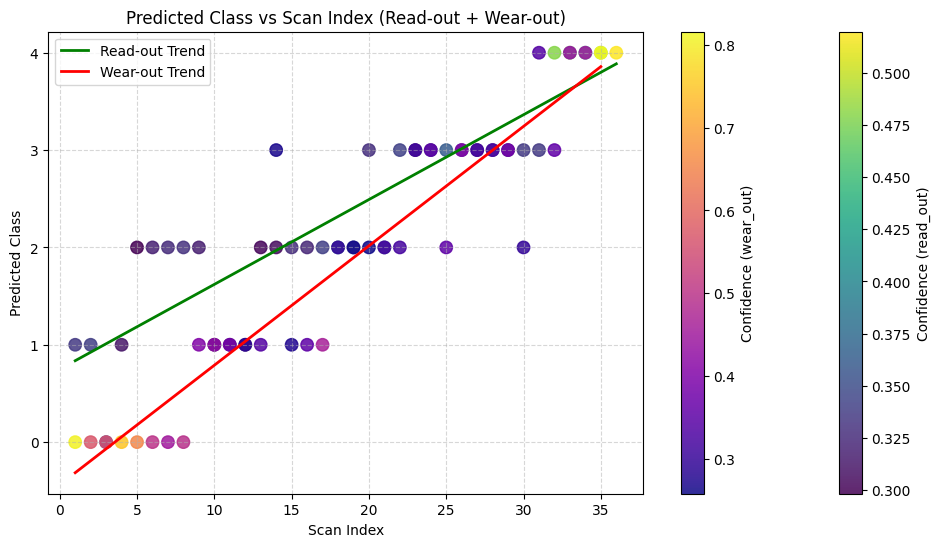

Quality: Poor (Class 3)
Confidence: 0.254
Predicted Class: 3
Scan Index: 32
Predicted Reward: 0.6243
Actual Reward: 0.4807


In [86]:
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_trained_model('ibw_reward_model.pth', num_classes=5, device=device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Read-out folder predictions ---
file = "exp_data/June 18/read_out/Read_out_0032.ibw"
summarize_ibw_file(file)
read_out_folder = os.path.dirname(file)
read_out_files = sorted([os.path.join(read_out_folder, f) for f in os.listdir(read_out_folder) if f.lower().endswith(".ibw")])

model_metadata_path = "model_training_metadata.pkl"
results_read = predict_with_training_metadata(model, read_out_files, model_metadata_path, device)

# --- Wear-out folder predictions ---
wear_out_folder = read_out_folder.replace("read_out", "wear_out")
wear_out_files = sorted([os.path.join(wear_out_folder, f) for f in os.listdir(wear_out_folder) if f.lower().endswith(".ibw")])
results_wear = predict_with_training_metadata(model, wear_out_files, model_metadata_path, device)

# --- Combine for plotting ---
import matplotlib.pyplot as plt

# Read-out
scan_indices_read = [r.get('scan_index', r.get('scan_index_used', i + 1)) for i, r in enumerate(results_read)]
predicted_classes_read = [r['predicted_class'] for r in results_read]
confidences_read = [r['confidence'] for r in results_read]

# Wear-out (reset scan index to start from 1)
scan_indices_wear = [i + 1 for i in range(len(results_wear))]
predicted_classes_wear = [r['predicted_class'] for r in results_wear]
confidences_wear = [r['confidence'] for r in results_wear]

# Plot both
import numpy as np

plt.figure(figsize=(12, 6))
scatter1 = plt.scatter(scan_indices_read, predicted_classes_read, c=confidences_read, cmap='viridis', s=80, alpha=0.85)
scatter2 = plt.scatter(scan_indices_wear, predicted_classes_wear, c=confidences_wear, cmap='plasma', s=80, alpha=0.85)

# Add trendline for read-out
z_read = np.polyfit(scan_indices_read, predicted_classes_read, 1)
p_read = np.poly1d(z_read)
plt.plot(scan_indices_read, p_read(scan_indices_read), color='green', linewidth=2, label='Read-out Trend')

# Add trendline for wear-out
z_wear = np.polyfit(scan_indices_wear, predicted_classes_wear, 1)
p_wear = np.poly1d(z_wear)
plt.plot(scan_indices_wear, p_wear(scan_indices_wear), color='red', linewidth=2, label='Wear-out Trend')

plt.xlabel('Scan Index')
plt.ylabel('Predicted Class')
plt.title('Predicted Class vs Scan Index (Read-out + Wear-out)')
plt.yticks(range(5), ['0', '1', '2', '3', '4'])
plt.colorbar(scatter1, label='Confidence (read_out)', orientation='vertical')
plt.colorbar(scatter2, label='Confidence (wear_out)', orientation='vertical')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print(f"Quality: {result['quality_description']}")
print(f"Confidence: {result['confidence']:.3f}")
print(f"Predicted Class: {result['predicted_class']}")
print(f"Scan Index: {result['scan_index']}")
print(f"Predicted Reward: {result['predicted_reward_original']:.4f}")
print(f"Actual Reward: {result['actual_reward']:.4f}")

## Model trained with 1 epoch appears to rever to binary classifier... not sure if this can be used to our advantage but may want to explore using this to indicate when confidence dips as an indicator about the probabibility the tip is about to break

In [14]:
x = np.linspace(350, 100, 20)
print(x)

[350.         336.84210526 323.68421053 310.52631579 297.36842105
 284.21052632 271.05263158 257.89473684 244.73684211 231.57894737
 218.42105263 205.26315789 192.10526316 178.94736842 165.78947368
 152.63157895 139.47368421 126.31578947 113.15789474 100.        ]


## Methods to Train
We can now consider various methods to train the ML based on the data that we have. The end goal is to have some model that can take real-time data and make a prediction based off the small sample. This can be done since we are already cropping the images, so assuming that a small piece of information is good enough, we can use this trained model to make predictions before a final image is created.

This requires a bit of interfacing with the actual AFM machine, but from the software standpoint, it can be done in realtime before the next sample cropped image is ready.